# Using simulation to assess trigger-generating mechanisms for digital health interventions
A fork of custom OpenAI Gym / Gymnasium environment simulating patients behavior. Adopted for the _AI in Biomedical Informatics_ course.

## Authors
Łukasz Andryszewski 151930
Eliza Czaplicka 151963
Michał Kałmucki 151944
Jędrzej Pacanowski 151952

# The task

The task is the create a simulation environment for patients behaviour, particuraly performing some health related activity. This behaviour is modeled in accordance to the [Fogg's model][2]: 
$$\text{Behaviour} = \begin{cases}
1 & \text{Motivarion} \times \text{Ability} \times \text{Trigger}  > \text{action threshold} \\
0 & otherwise
\end{cases}$$

# Patient profiles
Patient profiles were modeled based on the most common answers to the survery in [1]. The table was presented as follows:

|Nr.| Question                                                                 | 0   | 1   | 2   | 3       |
|-|--------------------------------------------------------------------------|-----|-----|-----|---------|
|$Q_1$| If I see that I perform health-related activities better than my peers, I feel motivated | No  | No  | Yes | Neutral |
|$Q_2$| I am keen to perform a simple activity for a longer time when I want to break my own record | No  | No  | Yes | Yes     |
|$Q_3$| I am keen to perform a simple activity for a longer time when I compete with others | No  | No  | Yes | Neutral |
|$Q_4$| When I am stressed, I am unlikely to respond to any reminders for health-related activities | No  | Yes | Yes | Neutral |
|$Q_5$| When I am tired, I am unlikely to respond to any reminders for health-related activities | No  | Yes | Yes | Yes     |

The behaviour of the patients were modeled with Python Gymnasium in [3]. We additionally label the profiles for convenience $P_0$ - neutral, $P_1$ - unmotivated, $P_2$ - social, $P_3$ - mixed. 

Each of the Questions $Q_i$ were interpreted as different personality traits:

|Question|Trait|Nr.|
|--------|-----|--|
|$Q_1$| social influence|$t_1$|
|$Q_2$| ambitious |$t_2$|
|$Q_3$| competetiveness |$t_3$|
|$Q_4$| stress resistance |$t_4$|
|$Q_5$| fatigue resistance |$t_5$|

Traits $t_1$, $t_2$ and $t_3$ were interpreted to influence the $\text{Motivation}$ variable in the Fogg's model. The reasoning is that $Q_1$ directly mentions being motivated, while $Q_2$ and $Q_3$ describe being enthusiastic of doing the tasks for longer under certain conditions. Additionally these were interpreted as being able to only influence the motivation positively.

While traits $t_4$ and $t_5$ were interpreted to influence the trigger, as their question directly influences if the patient will respond to a prompt under certain conditions. Here the lack of these traits were to be interpreted as a negative to the trigger, whilst their presence did not influence it positively.

Each of the profiles were assigned different trait weights according to the most common answers in the survey.

|Trait\Profile|0|1|2|3|
|-----|-|-|-|-|
|$t_1$|0.0|0.0|1.0|0.5|
|$t_2$|0.0|0.0|1.0|1.0|
|$t_3$|0.0|0.0|1.0|0.5|
|$t_4$|1.0|0.0|0.0|0.5|
|$t_5$|1.0|0.0|0.0|0.0|

## How traits were modeled

- **$t_1$ Social influence** - a score of the patient is saved each time he performs an activity. The score is sampled from a normal distribution according to his experience with the activity $N(n_{\text{performances}}+\text{last\_score}, 1.5)$. The score of the group is sampled like $N(n_{\text{performances}}, 1)$, so the group is always around the level of the patient. If the patient peformed better than the group $1 \cdot \text{social\_influence}$ is added to **motivation**.

- **$t_2$ Ambitious** - using the list of recorded scores mentioned before, we check if the last score is higher than the previous one. Additionally we check if the patient is tired from performing the acitivty multiple times, as the question states "perform a simple activity for a longer time". If both are true, then $1 \cdot \text{ambitious}$ is added to **motivation**.

- **$t_3$ Competetiveness** - each activity is assumed to be performed in a group. As in the previous question we check if the patient is tired. If both are true, then $1 \cdot \text{competetiveness}$ is added to **motivation**.

- **$t_4$ Stress resistance** - stress is defined in [4] as a state of high arousal and low valiance. When stress is detected a penalty of $1 \cdot (1-\text{stress\_resistance})$ is applied to the **trigger**.

- **$t_5$ Fatigue resistance** - we define fatigue as either the patient getting less 7 hours of sleep or being tired of repeating the activity. When fatigue is detected a penalty of $1 \cdot (1-\text{fatigue\_resistance})$ is applied to the **trigger**.

# Results analysis

In this section the results of an experiment runs in Gymnasium for different stimuli methods are shown and analyzed.

The used methods used were:

- Random prompting
- Supervised adaptive model
- Deep Q Network (DQN)
- Proximal Policy Optimization (PPO)
- Advantage Actor Critic (AAC)

For each of the four profiles, each method was run for 500 runs over 56 days. The behaviour threshold was set to 20, which did not change during the simulation. The profile of the patient was also constant.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

In [2]:
df = pd.DataFrame()
if not Path("full_data.csv").exists():
    for filepath in tqdm(Path("./data").rglob("*.csv")):
        _,_,profile,_run = filepath.as_posix().split("/")
        file_name = _run.split(".")[0].split("_")[2:]
        if len(file_name) == 2:
            method, run_id = file_name
        else:
            method = file_name[0] + "_" + file_name[1]
            run_id = file_name[2]
        run_id = int(run_id[3:])
        data = pd.read_csv(filepath)
        data = data.rename(columns={"Unnamed: 0":"day"})
        data["method"] = method
        data["profile"] = profile
        data["run_id"] = run_id

        df = pd.concat([df, data], ignore_index=True)

    df.to_csv("full_data.csv", index=False)
else:
    df = pd.read_csv("full_data.csv")


In [3]:
df.head()

,day,response_ratio,activity performed,notifications,sleep,positive,non_stationary,method,profile,run_id
0,0,0.0,0,13,5,0,0,a2c,mixed,0
1,1,0.0,0,11,1,0,0,a2c,mixed,0
2,2,0.0,0,7,3,0,0,a2c,mixed,0
3,3,0.0,0,12,7,1,0,a2c,mixed,0
4,4,0.0,0,8,2,0,0,a2c,mixed,0


In [4]:
profiles = ["neutral","unmotivated","social","mixed"]
methods = df.method.unique()

Number of runs where no activity was performed:

In [5]:
(df.groupby(["method","profile","run_id"])["activity performed"].sum()==0).groupby(["method","profile"]).sum().reset_index().pivot(index=["method"],columns="profile", values="activity performed")

profile,mixed,neutral,social,unmotivated
method,,,,
a2c,141,175,103,201
adaptive_sup3,206,291,220,278
dqn,216,205,193,264
ppo,188,238,159,255
random,55,133,43,119


In [6]:
df_means = df.groupby(["method","profile","day"]).mean().reset_index().drop(columns=["run_id"])

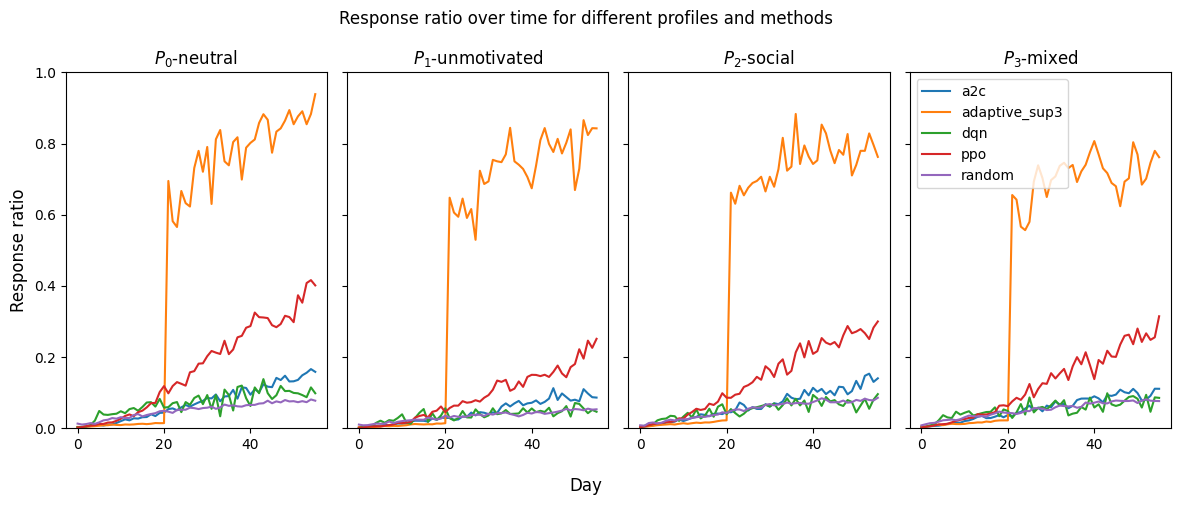

In [14]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,5),sharey=True,sharex=True)
axs[0].set_ylim(0,1)
for i, profile in enumerate(profiles):
    ax = axs[i]#[i//2][i%2]
    for method in methods:
        data = df_means[(df_means.method==method) & (df_means.profile==profile)]
        ax.plot(data.day, data["response_ratio"], label=method)
    ax.set_title(f"$P_{i}$-"+profile)
ax.legend(loc="upper left")
fig.supxlabel("Day")
fig.supylabel("Response ratio")
fig.suptitle("Response ratio over time for different profiles and methods")
fig.tight_layout()
plt.show()

Here is the table showing area under the graph for each method and profile: 

In [8]:
df.groupby(["method","profile","run_id"])["response_ratio"].sum().groupby(["method","profile"]).mean().reset_index().rename(columns={"response_ratio":"rr area"}).pivot(index=["method"],columns="profile")

rr area                                
profile           mixed   neutral    social unmotivated
method                                                 
a2c            2.048387  2.737024  2.434427    1.687374
adaptive_sup3  3.695126  2.185892  3.881575    2.091866
dqn            1.438909  1.887934  1.419406    0.988464
ppo            2.123578  3.389324  2.900894    1.392450
random         2.874112  2.860199  2.970221    1.899645

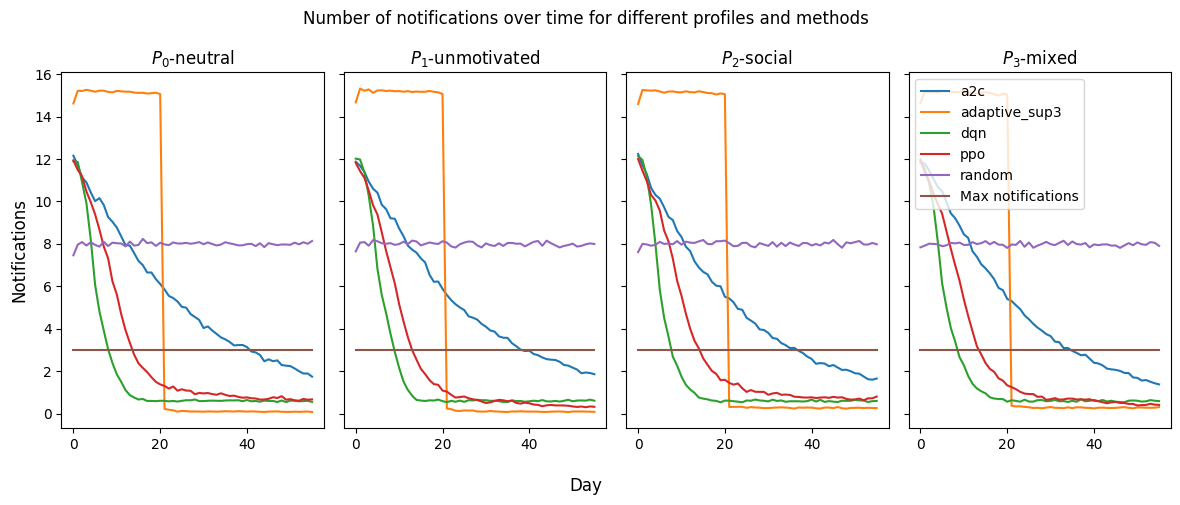

In [19]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,5),sharey=True,sharex=True)
for i, profile in enumerate(profiles):
    ax = axs[i]#[i//2][i%2]
    for method in methods:
        data = df_means[(df_means.method==method) & (df_means.profile==profile)]
        ax.plot(data.day, data["notifications"], label=method)
    ax.plot(data.day, np.ones(len(data.day))+2, label="Max notifications")
    ax.set_title(f"$P_{i}$-"+profile)
ax.legend(loc="upper left")
fig.supxlabel("Day")
fig.supylabel("Notifications")
fig.suptitle("Number of notifications over time for different profiles and methods")
fig.tight_layout()
plt.show()

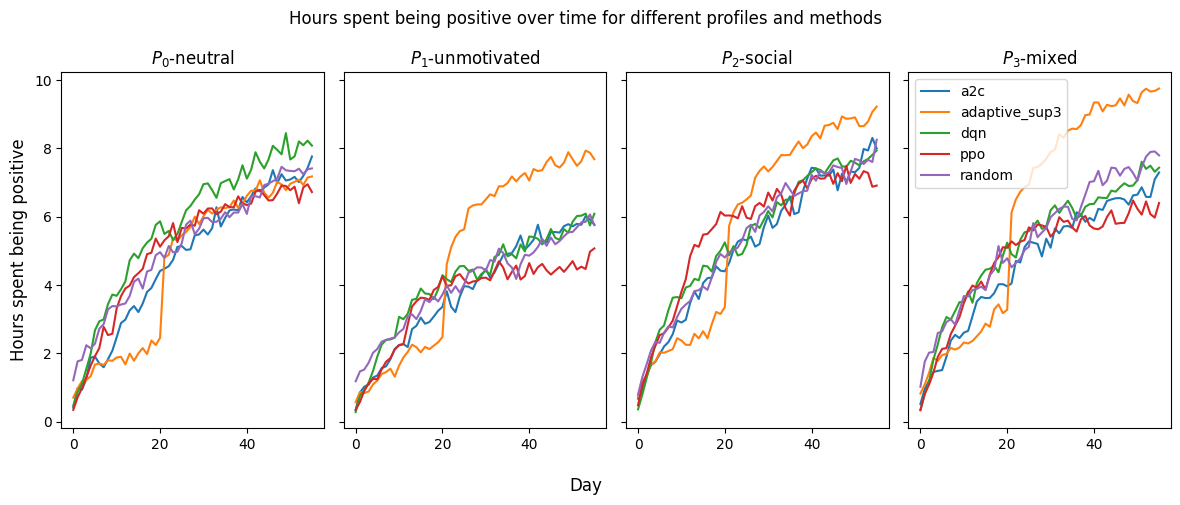

In [20]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,5),sharey=True,sharex=True)
for i, profile in enumerate(profiles):
    ax = axs[i]#[i//2][i%2]
    for method in methods:
        data = df_means[(df_means.method==method) & (df_means.profile==profile)]
        ax.plot(data.day, data["positive"], label=method)
    ax.set_title(f"$P_{i}$-"+profile)
ax.legend(loc="upper left")
fig.supxlabel("Day")
fig.supylabel("Hours spent being positive")
fig.suptitle("Hours spent being positive over time for different profiles and methods")
fig.tight_layout()
plt.show()

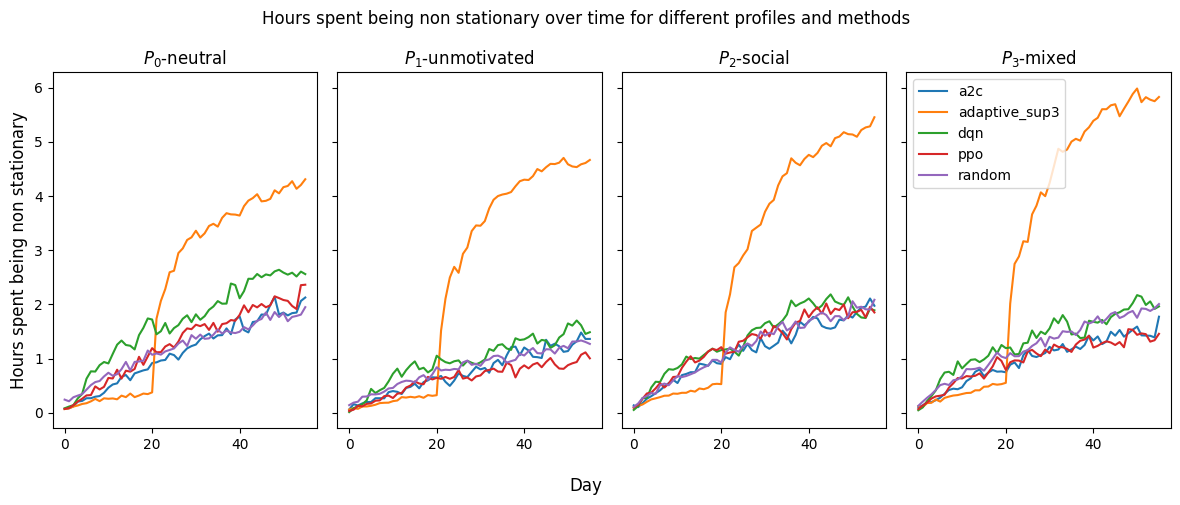

In [21]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,5),sharey=True,sharex=True)
for i, profile in enumerate(profiles):
    ax = axs[i]#[i//2][i%2]
    for method in methods:
        data = df_means[(df_means.method==method) & (df_means.profile==profile)]
        ax.plot(data.day, data["non_stationary"], label=method)
    ax.set_title(f"$P_{i}$-"+profile)
ax.legend(loc="upper left")
fig.supxlabel("Day")
fig.supylabel("Hours spent being non stationary")
fig.suptitle("Hours spent being non stationary over time for different profiles and methods")
fig.tight_layout()
plt.show()

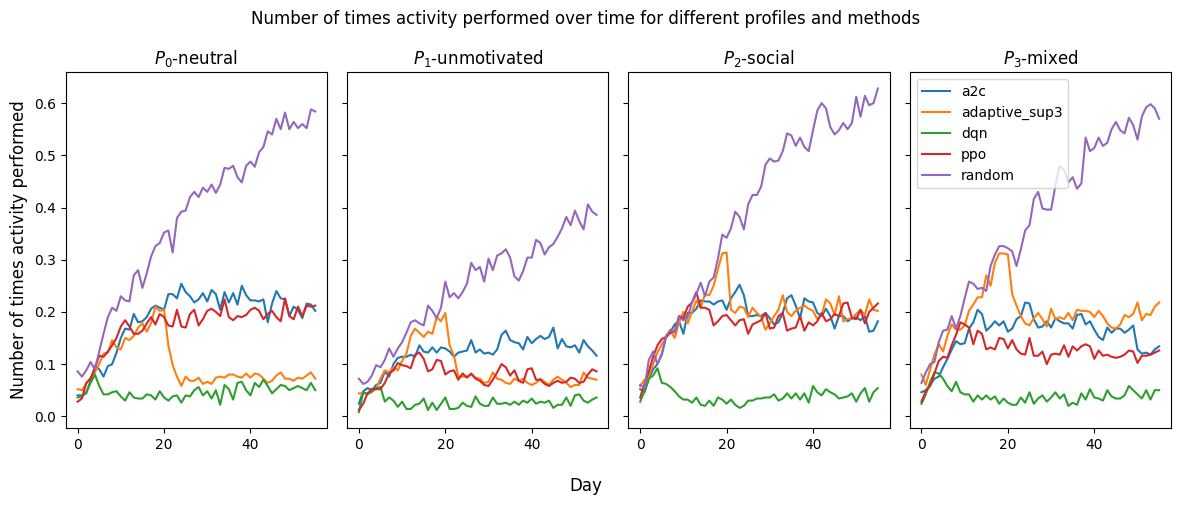

In [22]:
fig, axs = plt.subplots(nrows=1,ncols=4,figsize=(12,5),sharey=True,sharex=True)
for i, profile in enumerate(profiles):
    ax = axs[i]#[i//2][i%2]
    for method in methods:
        data = df_means[(df_means.method==method) & (df_means.profile==profile)]
        ax.plot(data.day, data["activity performed"], label=method)
    ax.set_title(f"$P_{i}$-"+profile)
ax.legend(loc="upper left")
fig.supxlabel("Day")
fig.supylabel("Number of times activity performed")
fig.suptitle("Number of times activity performed over time for different profiles and methods") 
fig.tight_layout()
plt.show()

The modeled profiles influence the results of the experiments. The profile **neutral** with the way the traits are configured can be treated as the baseline for comparison. It is notable that the **adaptive supervised after 3 weeks** is the best when it comes to the area under the graph for 3 profiles: **unmotivated**, **social** and **mixed**. For the **neutral** profile the **PPO** method had the largest area. It is worth noting that the **random** method produces the least amount of runs where no activity is performed. When it comes to the profile comparison, **unmotivated** was the unhappiest profile for any method, spending the least amount of hours happy. It was also the least active. In contrast the **social** and **mixed** profiles were much happier.

# Conclusions


# References

[1]: A. Lisowska, S. Lavy, Sz. Wilk, M. Peleg, Personality and Habit Formation: Is There a Link?
in: SMARTERCARE 2021. Workshop Proceedings, CEUR-WS, vol. 360, CEUR, 2021, pp. 42-47.  https://ceur-ws.org/Vol-3060/paper-5.pdf. 

[2]: B.J. Fogg, Tiny Habits: The Small Changes That Change Everything. 2019.

[3]: A Reinforcement Learning Approach to Invoking Positive Behavioral Change https://github.com/sysmon37/aibi-dhi-simulator

[4]: A. Lisowska, Sz. Wilk, M. Peleg, From Personalized Timely Notification to Healthy Habit Formation: A Feasibility Study of Reinforcement Learning Approaches on Synthetic Data, 7 in: SMARTERCARE 2021. Workshop Proceedings, CEUR-WS, vol. 360, CEUR, 2021, pp. 7-
18. http://ceur-ws.org/Vol-3060/paper-2.pdf